# 12 — EDA fase 3: dinámica temporal

**Pregunta guía:** ¿qué estructura temporal tiene la serie de casos y qué implica para pronosticar a 4 semanas?

Dataset: `data/silver/integrado/meteo_socio_epi_piura_2017_2025.csv` (solo lectura). Rezagos, anomalías, temporadas y líneas base se calculan **en memoria** para describir; nada se guarda en `data/` ni es una feature. Las líneas base ingenuas solo dimensionan la dificultad: no son modelos del proyecto.

Supuestos de trabajo (pendientes de decisión de Rosa): 2025 incluido pero marcado; población del dataset; los tres distritos sin registros incluidos. Como referencia binaria se usa la definición D1 de la fase 2 (tasa ≥ 10 por 100 000 hab.), **solo para ilustrar**; no es una elección.

Etiquetas: **Observación** · **Hipótesis** · **Implicación**.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss, pacf

from src.eda.carga import cargar_integrado, OBJETIVO
from src.eda.objetivo import tasa_100k, brote_umbral_tasa, brote_aumento_sostenido, rachas
from src.eda.temporal import (
    acf_simple, acf_por_grupo, perfil_normalizado, semana_valle, asignar_temporada,
    prediccion_persistencia, prediccion_estacional, metricas_binarias,
)
from src.eda.estilo import aplicar_estilo, guardar_figura, guardar_metricas, COLORES

aplicar_estilo()
FASE = "fase3_temporal"
H = 4          # horizonte de pronóstico del proyecto (semanas)
M = {"horizonte_semanas": H}

df = cargar_integrado()
log_casos = np.log1p(df[OBJETIVO])                       # en memoria
regional = df.groupby("semana_inicio")[OBJETIVO].sum()
log_regional = np.log1p(regional)
brote_ref = brote_umbral_tasa(df, 10)                     # D1 ilustrativa
print(df.shape, "| positivos D1:", int(brote_ref.sum()))

(30485, 35) | positivos D1: 4076


## 1. Series regional y por provincia: regímenes

**Qué quiero saber:** si la serie tiene un nivel estable o cambia de régimen (brotes de 2017 y 2023, silencio 2018-2020, ruptura de fuente en 2025), y si las provincias siguen la misma dinámica.

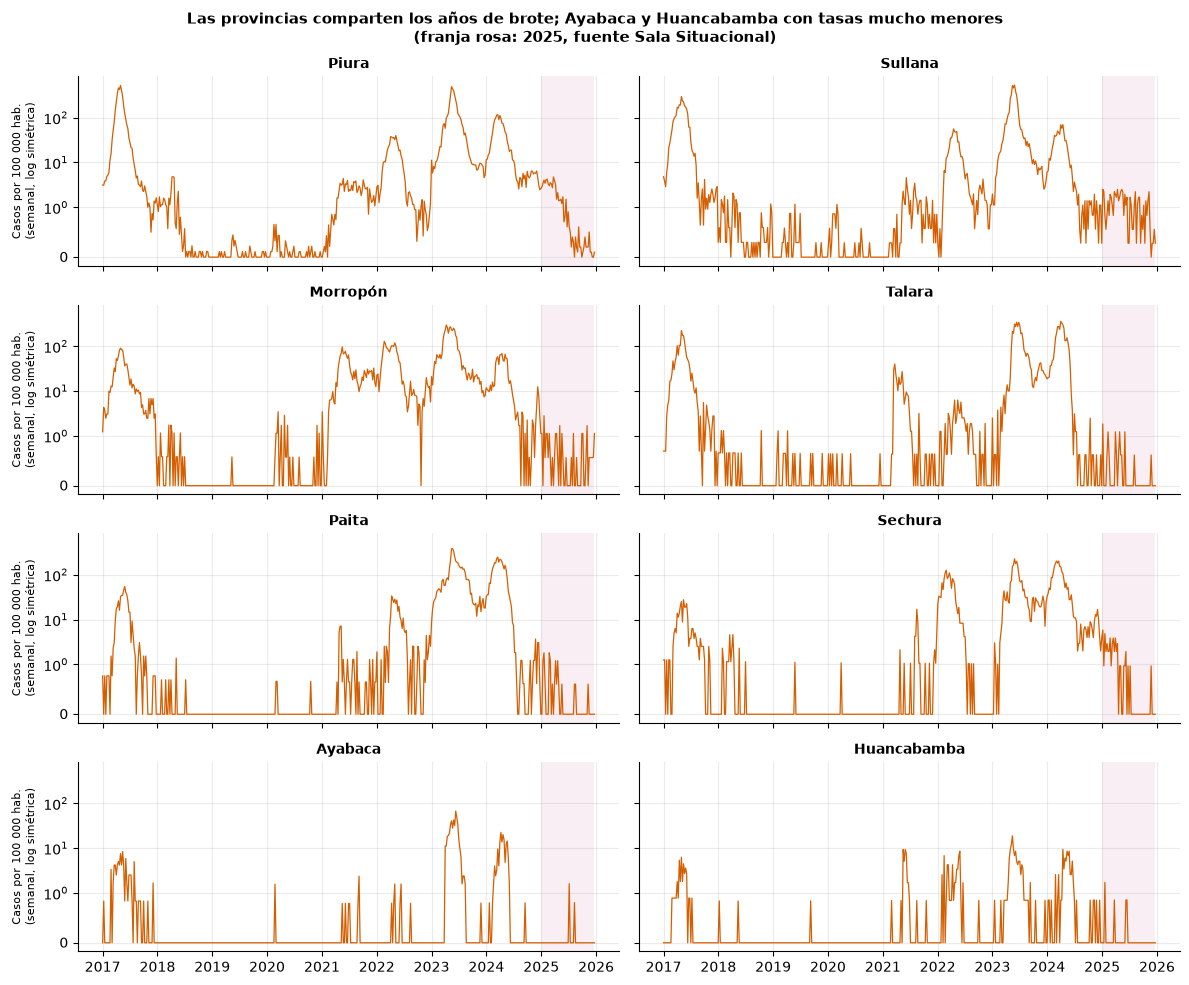

Mediana de casos regionales por semana entre temporadas (semanas 35-52): {2017: 28.0, 2018: 1.0, 2019: 0.5, 2020: 0.5, 2021: 62.5, 2022: 31.5, 2023: 249.0, 2024: 67.0, 2025: 5.5}
Spearman entre series provinciales (mín, mediana, máx): [0.51, 0.65, 0.86]
ADF (H0: raíz unitaria) p = 0.088; KPSS (H0: estacionaria) p ≤ 0.01 (statsmodels acota el p de KPSS en [0.01, 0.1])


In [2]:
prov = df.groupby(["provincia", "semana_inicio"]).agg(casos=(OBJETIVO, "sum"), pob=("poblacion", "sum")).reset_index()
prov["tasa"] = tasa_100k(prov["casos"], prov["pob"])
orden_prov = prov.groupby("provincia")["casos"].sum().sort_values(ascending=False).index

fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True, sharey=True)
for ax, p in zip(axes.flat, orden_prov):
    g = prov[prov["provincia"] == p]
    ax.plot(g["semana_inicio"], g["tasa"], color=COLORES["casos"], lw=0.9)
    ax.axvspan(pd.Timestamp("2024-12-29"), g["semana_inicio"].max(), color=COLORES["resalte"], alpha=0.12, lw=0)
    ax.set_yscale("symlog", linthresh=1)
    ax.set_title(p, fontsize=10)
for ax in axes[:, 0]:
    ax.set_ylabel("Casos por 100 000 hab.\n(semanal, log simétrica)", fontsize=8)
fig.suptitle("Las provincias comparten los años de brote; Ayabaca y Huancabamba con tasas mucho menores\n(franja rosa: 2025, fuente Sala Situacional)",
             fontsize=11, fontweight="bold")
fig.tight_layout()
guardar_figura(fig, FASE, "01_series_por_provincia")
plt.show()

# Nivel entre temporadas: mediana de casos regionales semanales en las semanas 35-52 de cada año
entre = df[df["semana"].between(35, 52)].groupby(["anio", "semana"])[OBJETIVO].sum().groupby("anio").median()
M["mediana_casos_regionales_sem35_52_por_anio"] = {int(a): float(v) for a, v in entre.items()}
print("Mediana de casos regionales por semana entre temporadas (semanas 35-52):", M["mediana_casos_regionales_sem35_52_por_anio"])

# Correlación entre provincias de la serie semanal log1p (Spearman), solo como resumen de sincronía
ancho_prov = np.log1p(prov.pivot(index="semana_inicio", columns="provincia", values="casos"))
corr_prov = ancho_prov.corr(method="spearman")
tri = corr_prov.where(np.triu(np.ones(corr_prov.shape, dtype=bool), 1)).stack()
M["spearman_entre_provincias_min_mediana_max"] = [round(float(tri.min()), 2), round(float(tri.median()), 2), round(float(tri.max()), 2)]
print("Spearman entre series provinciales (mín, mediana, máx):", M["spearman_entre_provincias_min_mediana_max"])

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    adf_p = adfuller(log_regional)[1]
    kpss_p = kpss(log_regional, nlags="auto")[1]
M["adf_pvalor_log_regional"] = round(float(adf_p), 3)
M["kpss_pvalor_log_regional"] = round(float(kpss_p), 3)
print(f"ADF (H0: raíz unitaria) p = {M['adf_pvalor_log_regional']}; KPSS (H0: estacionaria) p ≤ {M['kpss_pvalor_log_regional']} (statsmodels acota el p de KPSS en [0.01, 0.1])")

**Observación.** Las provincias comparten los mismos años de brote, y sus series semanales están positivamente correlacionadas (cifras arriba). El nivel **entre temporadas** (semanas 35-52) cambia de régimen: en 2017 es moderado, en 2018-2020 es casi nulo (silencio), desde 2021 vuelve a ser alto (2023 el máximo) y en 2025 es bajo, año que además viene de otra fuente. Las pruebas ADF y KPSS apuntan en la misma dirección: no hay evidencia de estacionariedad. Con dos grandes brotes en 9 años, eso es esperable y las pruebas tienen poco poder; se reportan solo como referencia.
**Hipótesis.** El nivel basal más alto desde 2021 podría reflejar transmisión sostenida entre temporadas o cambios de notificación; el dataset no permite distinguirlos.
**Implicación.**
- Hay al menos tres regímenes: brote 2017, silencio 2018-2020 y nivel basal alto 2021-2024, con 2025 aparte por la fuente. Un modelo entrenado con los primeros vería una dinámica distinta a la de los últimos.
- El nivel basal reciente es información útil, porque la persistencia la captura.
- Normalizar o estandarizar la serie con estadísticas de todo el periodo mezclaría regímenes y usaría información futura.

## 2. Estacionalidad: ¿cuándo empieza y culmina la temporada?

**Qué quiero saber:** si hay un ciclo anual estable, en qué semana epidemiológica está el valle (el mejor punto para separar temporadas) y si la semana del pico cambia entre brotes. Cada año se divide por su máximo, para comparar formas y no magnitudes.

Valle estacional (mínimo de la mediana del perfil desde la semana 27): semana 35. Máximo de la mediana del perfil: semana 20.
Semana del pico por año: {2017: 18, 2018: 15, 2019: 22, 2020: 10, 2021: 20, 2022: 16, 2023: 20, 2024: 14, 2025: 4}


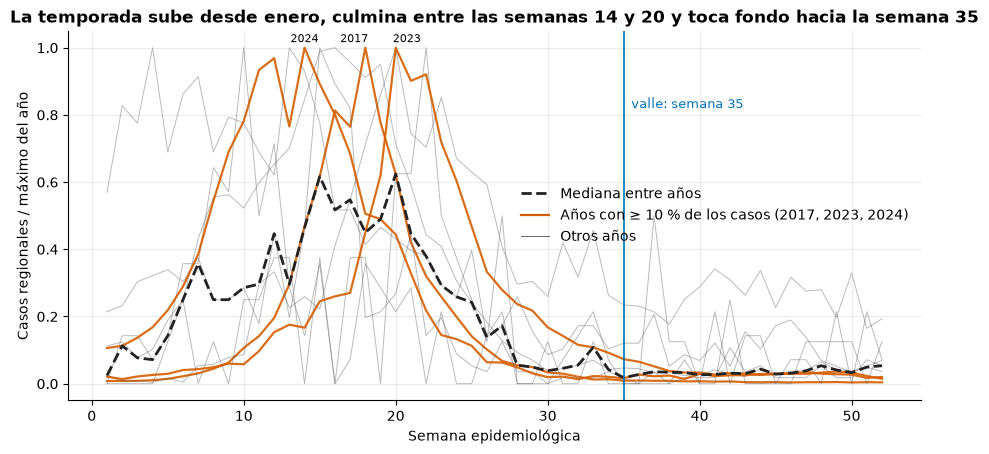

In [3]:
perfil = perfil_normalizado(df).loc[1:52]   # la semana 53 solo existe en 2020: se excluye del perfil
valle = semana_valle(perfil, desde=27)
mediana_perfil = perfil.median(axis=1)
picos = df.groupby(["anio", "semana"])[OBJETIVO].sum().groupby("anio").idxmax().map(lambda t: t[1])
casos_anio = df.groupby("anio")[OBJETIVO].sum()
grandes = casos_anio[casos_anio >= 0.1 * casos_anio.sum()].index
M["semana_valle"] = valle
M["semana_mediana_perfil_maximo"] = int(mediana_perfil.idxmax())
M["semana_pico_por_anio"] = {int(a): int(s) for a, s in picos.items()}
M["semana_pico_anios_grandes"] = {int(a): int(picos[a]) for a in grandes}
M["pct_semanas_27_52_bajo_10pct_del_maximo_mediana"] = round(float((mediana_perfil.loc[27:52] < 0.1).mean() * 100), 1)
print(f"Valle estacional (mínimo de la mediana del perfil desde la semana 27): semana {valle}. "
      f"Máximo de la mediana del perfil: semana {M['semana_mediana_perfil_maximo']}.")
print("Semana del pico por año:", M["semana_pico_por_anio"])

fig, ax = plt.subplots(figsize=(11, 4.8))
for a in perfil.columns:
    destacado = a in grandes
    ax.plot(perfil.index, perfil[a], lw=1.6 if destacado else 0.7,
            color=COLORES["casos"] if destacado else COLORES["referencia"], alpha=0.9 if destacado else 0.45)
    if destacado:
        desfase = {2017: -8, 2023: 8}.get(a, 0)   # evita que se encimen etiquetas de picos cercanos
        ax.annotate(str(a), (picos[a], 1), xytext=(desfase, 4), textcoords="offset points", ha="center", fontsize=8)
ax.plot(mediana_perfil.index, mediana_perfil, color="#222222", lw=2, ls="--", label="Mediana entre años")
ax.axvline(valle, color=COLORES["clima"], lw=1.2)
ax.text(valle + 0.5, 0.82, f"valle: semana {valle}", color=COLORES["clima"], fontsize=9)
ax.plot([], [], color=COLORES["casos"], lw=1.6, label="Años con ≥ 10 % de los casos (2017, 2023, 2024)")
ax.plot([], [], color=COLORES["referencia"], lw=0.7, label="Otros años")
ax.set(xlabel="Semana epidemiológica", ylabel="Casos regionales / máximo del año",
       title=f"La temporada sube desde enero, culmina entre las semanas {min(M['semana_pico_anios_grandes'].values())} y {max(M['semana_pico_anios_grandes'].values())} y toca fondo hacia la semana {valle}")
ax.legend(loc="center right")
guardar_figura(fig, FASE, "02_perfil_estacional")
plt.show()

In [4]:
df["temporada"] = asignar_temporada(df["anio"], df["semana"], valle)   # columna solo en memoria
por_temp = df.groupby("temporada").agg(desde=("semana_inicio", "min"), hasta=("semana_inicio", "max"),
                                       semanas=("semana_inicio", "nunique"), casos=(OBJETIVO, "sum"))
M["temporadas_casos"] = {int(t): int(v) for t, v in por_temp["casos"].items()}
M["temporadas_incompletas"] = [int(t) for t in por_temp.index if por_temp.loc[t, "semanas"] < 52]
# ¿Cuántos casos cambian de "año" al pasar de año calendario a temporada?
M["casos_2024_calendario_vs_temporada"] = [int(casos_anio[2024]), int(por_temp.loc[2024, "casos"])]
M["casos_semanas_1_a_valle_2024"] = int(df[(df["anio"] == 2024) & (df["semana"] < valle)][OBJETIVO].sum())
M["casos_semanas_valle_a_52_2023"] = int(df[(df["anio"] == 2023) & (df["semana"] >= valle)][OBJETIVO].sum())

# Sensibilidad de la semana de corte (30-40): perfil mediano, casos regionales y positivos D1 de 2023 en esa semana, y positivos D1 sumando todos los años
reg_as = df.groupby(["anio", "semana"])[OBJETIVO].sum()
sens = pd.DataFrame({
    "mediana_perfil": mediana_perfil.loc[30:40].round(3),
    "casos_regionales_2023": reg_as.xs(2023, level="anio").loc[30:40],
    "max_casos_regionales_otros_anios": reg_as.drop(2023, level="anio").unstack("anio").loc[30:40].max(axis=1),
    "D1_positivos_2023_en_la_semana": pd.Series({w: int(brote_ref[(df["semana"] == w) & (df["anio"] == 2023)].sum()) for w in range(30, 41)}),
    "D1_positivos_todos_los_anios_en_la_semana": pd.Series({w: int(brote_ref[df["semana"] == w].sum()) for w in range(30, 41)}),
})
M["sensibilidad_corte_semanas_30_40"] = {int(w): {k: float(v) for k, v in f.items()} for w, f in sens.iterrows()}
M["casos_regionales_2023_en_corte_min_max_sem30_40"] = [int(sens["casos_regionales_2023"].min()), int(sens["casos_regionales_2023"].max())]
entre_picos = regional[(regional.index > regional[regional.index.year == 2023].idxmax()) & (regional.index < regional[regional.index.year == 2024].idxmax())]
M["min_casos_regionales_semanales_entre_picos_2023_2024"] = int(entre_picos.min())
print(f"Casos regionales de 2023 en la semana de corte, para cortes entre la 30 y la 40: {M['casos_regionales_2023_en_corte_min_max_sem30_40']}; "
      f"mínimo semanal entre los picos de 2023 y 2024: {M['min_casos_regionales_semanales_entre_picos_2023_2024']} casos.")
display(sens)
print(f"Temporadas incompletas (bordes del panel): {M['temporadas_incompletas']}")
por_temp

Casos regionales de 2023 en la semana de corte, para cortes entre la 30 y la 40: [270, 1367]; mínimo semanal entre los picos de 2023 y 2024: 141 casos.


,mediana_perfil,casos_regionales_2023,max_casos_regionales_otros_anios,D1_positivos_2023_en_la_semana,D1_positivos_todos_los_anios_en_la_semana
30,0.039,1367,190.0,40,65
31,0.046,1160,169.0,41,74
32,0.055,943,117.0,39,62
33,0.108,881,111.0,35,55
34,0.042,751,75.0,37,51
35,0.018,595,57.0,34,49
36,0.027,532,70.0,29,40
37,0.036,421,56.0,31,45
38,0.034,309,62.0,27,39
39,0.033,271,61.0,25,35


Temporadas incompletas (bordes del panel): [2017, 2026]


,desde,hasta,semanas,casos
temporada,,,,
2017,2017-01-01,2017-08-20,34,43674
2018,2017-08-27,2018-08-19,52,1094
2019,2018-08-26,2019-08-18,52,89
2020,2019-08-25,2020-08-16,52,121
2021,2020-08-23,2021-08-22,53,2964
2022,2021-08-29,2022-08-21,52,12712
2023,2022-08-28,2023-08-20,52,74770
2024,2023-08-27,2024-08-18,52,36160
2025,2024-08-25,2025-08-17,52,2190


**Observación.** Hay un ciclo anual claro: la temporada sube desde las primeras semanas del año, culmina hacia la mitad del primer semestre y se apaga en el segundo. La semana del pico varía algunas semanas entre los años grandes. El valle marca un corte razonable de temporada, pero la mediana del perfil es casi plana en todo el segundo semestre, así que la semana exacta (35) es una convención más que un punto preciso (tabla de sensibilidad). Además, **2023 nunca se apaga**: con cualquier corte entre las semanas 30 y 40 hay cientos de casos regionales esa semana, y la serie no baja de unos pocos cientos por semana entre los picos de 2023 y 2024 (cifras arriba). Los brotes de 2023 y 2024 están conectados. Con ese corte, la primera temporada (2017) y la última (2026 = semanas del valle a 52 de 2025) quedan incompletas.
**Implicación.**
- Para validar conviene partir por **temporada** (del valle al valle) y no por año calendario, porque así se reduce el reparto de un mismo brote entre entrenamiento y prueba. Pero para 2023 → 2024 ningún corte lo evita: hace falta un **margen** (gap) de al menos el horizonte más el rezago máximo entre entrenamiento y prueba, y reportar que esas dos temporadas no son independientes.
- La semana epidemiológica aporta información estacional fuerte. Cómo codificarla (por ejemplo, seno y coseno o un perfil histórico) se decide en feature engineering, calculando el perfil **solo con temporadas de entrenamiento**.

## 3. Autocorrelación: ¿cuánto "sabe" el pasado propio a 4 semanas?

**Qué quiero saber:** la autocorrelación de `log1p(casos)` en los rezagos 1-26, (a) en la serie regional y (b) dentro de cada distrito (mediana entre distritos activos, con al menos 20 % de semanas con casos). Se hace en bruto y **sin estacionalidad**, restando a cada distrito su media por semana epidemiológica. Esa media usa todos los años: sirve para describir, pero en el modelado solo podría usar el pasado.

n_distritos_activos: 31
acf_regional_rezagos_1_4_8_13_26: {1: 0.974, 4: 0.936, 8: 0.862, 13: 0.739, 26: 0.51}
acf_regional_desest_rezagos_1_4_8: {1: 0.974, 4: 0.95, 8: 0.915}
acf_distrital_mediana_rezagos_1_4_8: {1: 0.926, 4: 0.827, 8: 0.648}
acf_distrital_desest_mediana_rezagos_1_4_8: {1: 0.92, 4: 0.84, 8: 0.687}
acf_distrital_rezago4_p25_p75: [0.761, 0.874]
acf_distrital_sin_nivel_temporada_mediana_rezagos_1_4_8: {1: 0.846, 4: 0.643, 8: 0.29}
acf_regional_sin_nivel_temporada_rezagos_1_4_8: {1: 0.889, 4: 0.691, 8: 0.401}
acf_regional_rezago4_dentro_de_cada_temporada: {2018: 0.563, 2019: -0.082, 2020: 0.267, 2021: 0.794, 2022: 0.713, 2023: 0.859, 2024: 0.658, 2025: 0.703}
pacf_regional_rezagos_1_a_4: {1: 0.976, 2: 0.396, 3: -0.004, 4: -0.142}


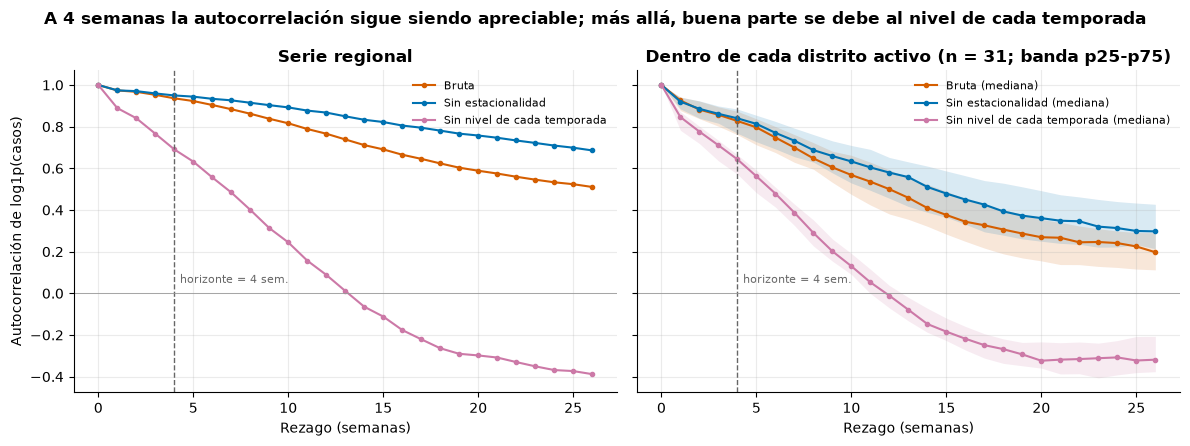

In [5]:
NL = 26
activos = df.groupby("ubigeo")[OBJETIVO].apply(lambda s: (s > 0).mean() >= 0.2)
activos = activos[activos].index
d_act = df[df["ubigeo"].isin(activos)].assign(l=log_casos)
d_act["l_desest"] = d_act["l"] - d_act.groupby(["ubigeo", "semana"])["l"].transform("mean")
d_act["l_sin_nivel"] = d_act["l"] - d_act.groupby(["ubigeo", "temporada"])["l"].transform("mean")   # quita el nivel de cada temporada
reg_desest = log_regional - log_regional.groupby(regional.index.map(lambda f: df.loc[df["semana_inicio"] == f, "semana"].iloc[0])).transform("mean")

acf_reg = acf_simple(log_regional.to_numpy(), NL)
acf_reg_d = acf_simple(reg_desest.to_numpy(), NL)
acf_dis = acf_por_grupo(d_act, "l", NL)
acf_dis_d = acf_por_grupo(d_act, "l_desest", NL)
acf_dis_n = acf_por_grupo(d_act, "l_sin_nivel", NL)
temp_reg = df.drop_duplicates("semana_inicio").set_index("semana_inicio")["temporada"]
reg_sin_nivel = log_regional - log_regional.groupby(temp_reg).transform("mean")
acf_reg_n = acf_simple(reg_sin_nivel.to_numpy(), NL)
# ACF regional en el rezago 4 dentro de cada temporada completa
acf4_temp = {int(t): round(float(acf_simple(g.to_numpy(), 4)[4]), 3) for t, g in log_regional.groupby(temp_reg) if len(g) >= 52}
pacf_reg = pacf(log_regional, nlags=8)

M["n_distritos_activos"] = int(len(activos))
M["acf_regional_rezagos_1_4_8_13_26"] = {k: round(float(acf_reg[k]), 3) for k in (1, 4, 8, 13, 26)}
M["acf_regional_desest_rezagos_1_4_8"] = {k: round(float(acf_reg_d[k]), 3) for k in (1, 4, 8)}
M["acf_distrital_mediana_rezagos_1_4_8"] = {k: round(float(acf_dis[k].median()), 3) for k in (1, 4, 8)}
M["acf_distrital_desest_mediana_rezagos_1_4_8"] = {k: round(float(acf_dis_d[k].median()), 3) for k in (1, 4, 8)}
M["acf_distrital_rezago4_p25_p75"] = [round(float(acf_dis[4].quantile(q)), 3) for q in (0.25, 0.75)]
M["acf_distrital_sin_nivel_temporada_mediana_rezagos_1_4_8"] = {k: round(float(acf_dis_n[k].median()), 3) for k in (1, 4, 8)}
M["acf_regional_sin_nivel_temporada_rezagos_1_4_8"] = {k: round(float(acf_reg_n[k]), 3) for k in (1, 4, 8)}
M["acf_regional_rezago4_dentro_de_cada_temporada"] = acf4_temp
M["pacf_regional_rezagos_1_a_4"] = {k: round(float(pacf_reg[k]), 3) for k in range(1, 5)}
for k in ["n_distritos_activos", "acf_regional_rezagos_1_4_8_13_26", "acf_regional_desest_rezagos_1_4_8",
          "acf_distrital_mediana_rezagos_1_4_8", "acf_distrital_desest_mediana_rezagos_1_4_8",
          "acf_distrital_rezago4_p25_p75", "acf_distrital_sin_nivel_temporada_mediana_rezagos_1_4_8",
          "acf_regional_sin_nivel_temporada_rezagos_1_4_8", "acf_regional_rezago4_dentro_de_cada_temporada", "pacf_regional_rezagos_1_a_4"]:
    print(f"{k}: {M[k]}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
rez = np.arange(NL + 1)
axes[0].plot(rez, acf_reg, color=COLORES["casos"], marker="o", ms=3, label="Bruta")
axes[0].plot(rez, acf_reg_d, color=COLORES["clima"], marker="o", ms=3, label="Sin estacionalidad")
axes[0].plot(rez, acf_reg_n, color=COLORES["resalte"], marker="o", ms=3, label="Sin nivel de cada temporada")
axes[0].set_title("Serie regional")
for serie, color, lab in [(acf_dis, COLORES["casos"], "Bruta"), (acf_dis_d, COLORES["clima"], "Sin estacionalidad"),
                          (acf_dis_n, COLORES["resalte"], "Sin nivel de cada temporada")]:
    axes[1].plot(rez, serie.median(), color=color, marker="o", ms=3, label=f"{lab} (mediana)")
    axes[1].fill_between(rez, serie.quantile(0.25), serie.quantile(0.75), color=color, alpha=0.15, lw=0)
axes[1].set_title(f"Dentro de cada distrito activo (n = {M['n_distritos_activos']}; banda p25-p75)")
for ax in axes:
    ax.axvline(H, color=COLORES["referencia"], ls="--", lw=1)
    ax.text(H + 0.3, 0.05, f"horizonte = {H} sem.", fontsize=8, color=COLORES["referencia"])
    ax.axhline(0, color="#999999", lw=0.6)
    ax.set_xlabel("Rezago (semanas)")
    ax.legend(loc="upper right", fontsize=8)
axes[0].set_ylabel("Autocorrelación de log1p(casos)")
fig.suptitle("A 4 semanas la autocorrelación sigue siendo apreciable; más allá, buena parte se debe al nivel de cada temporada", fontweight="bold")
fig.tight_layout()
guardar_figura(fig, FASE, "03_autocorrelacion")
plt.show()

**Observación.** La autocorrelación bruta a 4 semanas es alta, tanto en la serie regional como dentro de cada distrito activo, y quitar la estacionalidad no la reduce. Pero la serie no es estacionaria (sección 1), y parte de esa autocorrelación viene del **nivel de cada temporada**, es decir, de los años de brote frente a los de silencio. Al restar a cada distrito su media por temporada, la autocorrelación en el rezago 4 baja y en el rezago 8 cae mucho más. Dentro de cada temporada, la autocorrelación regional en el rezago 4 varía mucho: es alta en las temporadas de brote y baja o nula en las de silencio (cifras arriba).
**Implicación.**
- El rezago 4 (el más cercano disponible a horizonte 4) es informativo aun dentro de la temporada. Los rezagos 6-8 aportan sobre todo información del **nivel** de la temporada, más que dinámica de corto plazo. En feature engineering conviene considerar el rezago 4-5 y resúmenes del nivel reciente (por ejemplo, la media de las últimas semanas conocidas) en lugar de muchos rezagos individuales. Es una recomendación, no una decisión.
- Por lo mismo, cualquier modelo tiene que superar una línea base de persistencia, que es exigente (sección 4).

## 4. Líneas base ingenuas a 4 semanas

Solo para dimensionar la dificultad. Para la fila t se usa:
- **persistencia:** el valor de t − 4 (lo último conocido al predecir);
- **estacional ingenua:** el valor de la misma semana epidemiológica del año anterior (alineado por año y semana, así la semana 53 de 2020 no desplaza a 2021);
- **cero:** predecir siempre 0.

Se evalúan dos cosas: el error absoluto medio en `log1p(casos)` y, para la marca binaria D1, la precisión, la sensibilidad y el F1, por año. También se miden los **arranques**: semanas con brote sin ningún brote en las 8 semanas previas del distrito, que la persistencia no puede anticipar por construcción.

In [6]:
d = df.assign(l=log_casos, b=brote_ref.astype(float))
pred = {"persistencia": prediccion_persistencia(d, "l", H), "estacional": prediccion_estacional(d, "l"), "cero": d["l"] * 0}
comun = pred["persistencia"].notna() & pred["estacional"].notna()      # mismas filas para comparar (desde 2018)
mae = {k: round(float((d["l"] - v)[comun].abs().mean()), 3) for k, v in pred.items()}
mae_anio = pd.DataFrame({k: (d["l"] - v)[comun].abs().groupby(d.loc[comun, "anio"]).mean() for k, v in pred.items()}).round(3)
M["mae_log1p_mismas_filas"] = mae
M["mae_log1p_por_anio"] = {k: {int(a): float(x) for a, x in col.items()} for k, col in mae_anio.items()}

pb = {"persistencia": prediccion_persistencia(d, "b", H), "estacional": prediccion_estacional(d, "b")}
M["binaria_D1"] = {k: {kk: (None if pd.isna(vv) else round(float(vv), 3)) if isinstance(vv, float) else vv for kk, vv in metricas_binarias(d["b"][comun], v[comun]).items()}
                   for k, v in pb.items()}
f1_anio = pd.DataFrame({k: {a: metricas_binarias(d["b"][comun & (d["anio"] == a)], v[comun & (d["anio"] == a)])["f1"]
                            for a in sorted(d.loc[comun, "anio"].unique())} for k, v in pb.items()}).round(3)
M["f1_D1_por_anio"] = {k: {int(a): (None if pd.isna(x) else float(x)) for a, x in col.items()} for k, col in f1_anio.items()}

# Arranques: brote en t sin ningún brote en t-1..t-8 del mismo distrito
previos = d.groupby("ubigeo")["b"].transform(lambda s: s.shift(1).rolling(8, min_periods=8).max())
arranque = (d["b"] == 1) & (previos == 0)
M["arranques_n"] = int(arranque.sum())
M["arranques_pct_de_positivos"] = round(float(arranque.sum() / d["b"].sum() * 100), 1)
M["arranques_por_anio"] = {int(a): int(v) for a, v in arranque.groupby(d["anio"]).sum().items()}
print("MAE log1p (mismas filas):", mae)
print("D1 binaria:", M["binaria_D1"])
print(f"Arranques (brote sin brote en las 8 semanas previas): {M['arranques_n']} = {M['arranques_pct_de_positivos']} % de los positivos D1;",
      "por año:", M["arranques_por_anio"])
display(mae_anio)
f1_anio

MAE log1p (mismas filas): {'persistencia': 0.208, 'estacional': 0.525, 'cero': 0.403}
D1 binaria: {'persistencia': {'n': 27105, 'positivos': 3314, 'precision': 0.735, 'recall': 0.736, 'f1': 0.735}, 'estacional': {'n': 27105, 'positivos': 3314, 'precision': 0.307, 'recall': 0.373, 'f1': 0.337}}
Arranques (brote sin brote en las 8 semanas previas): 249 = 6.1 % de los positivos D1; por año: {2017: 48, 2018: 9, 2019: 0, 2020: 4, 2021: 33, 2022: 42, 2023: 58, 2024: 36, 2025: 19}


,persistencia,estacional,cero
anio,,,
2018,0.079,0.650,0.069
2019,0.022,0.072,0.013
2020,0.034,0.030,0.021
2021,0.179,0.259,0.258
2022,0.307,0.498,0.547
2023,0.528,0.965,1.343
2024,0.400,1.011,0.845
2025,0.122,0.729,0.139


,persistencia,estacional
2018,0.000,0.028
2019,NaN,NaN
2020,0.143,0.000
2021,0.600,0.000
2022,0.684,0.240
2023,0.808,0.461
2024,0.741,0.509
2025,0.175,0.065


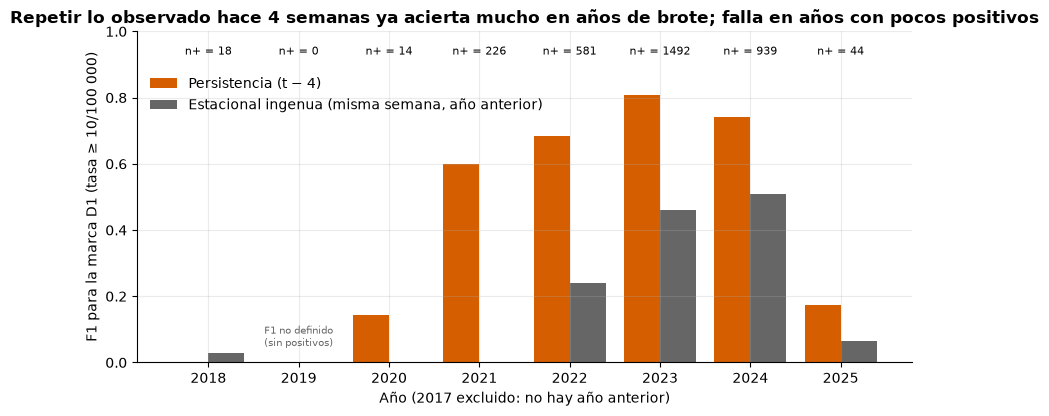

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.3))
x = np.arange(len(f1_anio))
ax.bar(x - 0.2, f1_anio["persistencia"], width=0.4, color=COLORES["casos"], label=f"Persistencia (t − {H})")
ax.bar(x + 0.2, f1_anio["estacional"], width=0.4, color=COLORES["referencia"], label="Estacional ingenua (misma semana, año anterior)")
positivos = d.loc[comun].groupby("anio")["b"].sum()
for i, a in enumerate(f1_anio.index):
    ax.text(i, 0.93, f"n+ = {int(positivos[a])}", ha="center", fontsize=8)
ax.set_xticks(x, f1_anio.index)
for i, a in enumerate(f1_anio.index):
    if f1_anio.loc[a].isna().all():
        ax.text(i, 0.05, "F1 no definido\n(sin positivos)", ha="center", fontsize=7, color=COLORES["referencia"])
ax.set(ylim=(0, 1), xlabel="Año (2017 excluido: no hay año anterior)", ylabel="F1 para la marca D1 (tasa ≥ 10/100 000)",
       title=f"Repetir lo observado hace {H} semanas ya acierta mucho en años de brote; falla en años con pocos positivos")
ax.legend(loc="upper left", bbox_to_anchor=(0, 0.9))
guardar_figura(fig, FASE, "04_lineas_base_f1_por_anio")
plt.show()

**Observación.** A 4 semanas, la persistencia tiene menor error que la estacional ingenua y que predecir siempre cero, y logra un F1 alto en la marca D1 durante los años de brote. Su desempeño cae en los años con pocos positivos; en un año sin positivos el F1 no está definido. La estacional ingenua es peor, porque los años son muy distintos entre sí. Los **arranques** (brotes sin brote en las 8 semanas previas) son una fracción de los positivos que la persistencia no puede anticipar por construcción (cifras arriba).
**Implicación.**
- La vara mínima para el modelo es la persistencia a 4 semanas, no el azar ni la estacionalidad. Un modelo que no la supere no aporta.
- El valor agregado real está en anticipar **arranques** y cambios de nivel. Por eso tiene sentido reportar métricas separadas para arranques; la fase 5 mide si el clima rezagado aporta ahí.
- Las métricas deben reportarse por temporada, porque varían mucho entre años.

## 5. Implicaciones para la validación temporal

**Qué quiero saber:** cómo quedarían los folds de dos esquemas temporales (por temporada, del valle al valle), cuántos positivos tendría cada uno y cuáles quedarían sin brotes:
- **A. Origen móvil (forward chaining):** se entrena con las temporadas anteriores y se prueba en la siguiente.
- **B. Dejar una temporada afuera:** se prueba en cada temporada entrenando con las demás, con un margen (gap) entre entrenamiento y prueba. Usa temporadas futuras en el entrenamiento, así que solo sirve para análisis de robustez, no como estimación honesta.

Referencias de positivos: D1 (nivel) y D4 (aumento sostenido, arranque) de la fase 2, con sus parámetros ilustrativos.

In [8]:
d4 = brote_aumento_sostenido(df, factor=2, ventana=8, k=3, minimo=5)
folds = []
temporadas = sorted(df["temporada"].unique())
for t in temporadas:
    prueba = df["temporada"] == t
    antes = df["temporada"] < t
    folds.append({
        "temporada_prueba": int(t), "semanas": int(df.loc[prueba, "semana_inicio"].nunique()),
        "D1_pos_prueba": int(brote_ref[prueba].sum()), "D4_pos_prueba": int(d4[prueba].sum()),
        "D1_pos_entrenamiento_A": int(brote_ref[antes].sum()), "D4_pos_entrenamiento_A": int(d4[antes].sum()),
        "D1_episodios_prueba": int(len(rachas(df[prueba].assign(_m=brote_ref[prueba]), "_m"))),
    })
folds = pd.DataFrame(folds).set_index("temporada_prueba")
UMBRAL_FOLD = 50
M["umbral_positivos_fold_util"] = UMBRAL_FOLD
M["folds"] = {int(t): {k: int(v) for k, v in f.items()} for t, f in folds.iterrows()}
M["temporadas_con_menos_de_umbral_D1"] = [int(t) for t in folds.index if folds.loc[t, "D1_pos_prueba"] < UMBRAL_FOLD]
M["temporadas_con_menos_de_umbral_D4"] = [int(t) for t in folds.index if folds.loc[t, "D4_pos_prueba"] < UMBRAL_FOLD]
M["pct_positivos_entrenamiento_fold_2021_de_temporada_2017"] = round(float(folds.loc[2017, "D1_pos_prueba"] / folds.loc[2021, "D1_pos_entrenamiento_A"] * 100), 1)
M["pct_D1_positivos_en_3_temporadas_mayores"] = round(float(folds["D1_pos_prueba"].nlargest(3).sum() / folds["D1_pos_prueba"].sum() * 100), 1)
print(f"Temporadas con < {UMBRAL_FOLD} positivos D1: {M['temporadas_con_menos_de_umbral_D1']}; con < {UMBRAL_FOLD} positivos D4: {M['temporadas_con_menos_de_umbral_D4']}")
print(f"Las 3 temporadas con más positivos D1 concentran el {M['pct_D1_positivos_en_3_temporadas_mayores']} %. "
      f"En el fold A con prueba 2021, el {M['pct_positivos_entrenamiento_fold_2021_de_temporada_2017']} % de los positivos de entrenamiento viene de la temporada 2017 (incompleta).")
folds

Temporadas con < 50 positivos D1: [2019, 2020, 2026]; con < 50 positivos D4: [2018, 2019, 2020, 2021, 2025, 2026]
Las 3 temporadas con más positivos D1 concentran el 76.8 %. En el fold A con prueba 2021, el 89.9 % de los positivos de entrenamiento viene de la temporada 2017 (incompleta).


,semanas,D1_pos_prueba,D4_pos_prueba,D1_pos_entrenamiento_A,D4_pos_entrenamiento_A,D1_episodios_prueba
temporada_prueba,,,,,,
2017,34,714,140,0,0,144
2018,52,65,7,714,140,44
2019,52,1,0,779,147,1
2020,52,14,0,780,147,12
2021,53,134,33,794,147,48
2022,52,628,123,928,180,116
2023,52,1148,300,1556,303,166
2024,52,1269,149,2704,603,238
2025,52,98,3,3973,752,67


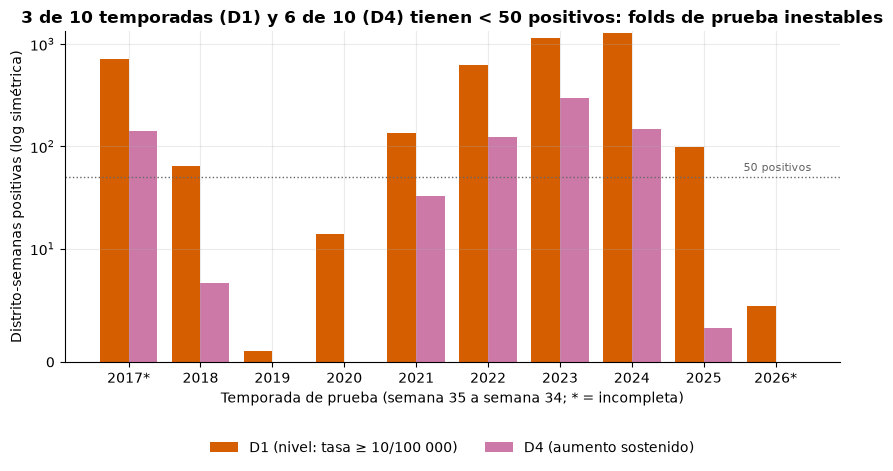

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.3))
x = np.arange(len(folds))
ax.bar(x - 0.2, folds["D1_pos_prueba"], width=0.4, color=COLORES["casos"], label="D1 (nivel: tasa ≥ 10/100 000)")
ax.bar(x + 0.2, folds["D4_pos_prueba"], width=0.4, color=COLORES["resalte"], label="D4 (aumento sostenido)")
ax.axhline(UMBRAL_FOLD, color=COLORES["referencia"], ls=":", lw=1)
ax.text(len(folds) - 0.5, UMBRAL_FOLD * 1.15, f"{UMBRAL_FOLD} positivos", ha="right", fontsize=8, color=COLORES["referencia"])
ax.set_yscale("symlog", linthresh=10)
etiquetas = [f"{t}{'*' if t in M['temporadas_incompletas'] else ''}" for t in folds.index]
ax.set_xticks(x, etiquetas)
ax.set(xlabel=f"Temporada de prueba (semana {valle} a semana {valle - 1}; * = incompleta)",
       ylabel="Distrito-semanas positivas (log simétrica)",
       title=f"{len(M['temporadas_con_menos_de_umbral_D1'])} de {len(folds)} temporadas (D1) y {len(M['temporadas_con_menos_de_umbral_D4'])} de {len(folds)} (D4) tienen < {UMBRAL_FOLD} positivos: folds de prueba inestables")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncols=2)
guardar_figura(fig, FASE, "05_positivos_por_temporada")
plt.show()

**Observación.** Los positivos se concentran en pocas temporadas. Varias temporadas (y las incompletas de los bordes) tienen muy pocos positivos: como folds de prueba darían métricas inestables o indefinidas. En el esquema A, los primeros folds entrenan casi solo con los positivos de la temporada 2017, que está incompleta (cifra arriba).
**Implicación: propuesta para discutir, no decisión.**
1. **Nunca** partir aleatoriamente por filas. La autocorrelación alta a 4 semanas filtraría información entre entrenamiento y prueba.
2. Esquema principal: **origen móvil por temporada**, evaluando solo en las temporadas con suficientes positivos (por ejemplo 2022, 2023 y 2024) y reportando cada fold por separado.
3. Robustez: **dejar una temporada afuera**, con un margen entre entrenamiento y prueba de al menos el horizonte más el rezago máximo usado. Dejar 2017 o 2023 afuera muestra cuánto depende el modelo de cada gran brote. El mismo margen hace falta en el origen móvil al pasar de 2023 a 2024, porque la transmisión no se interrumpe en el corte.
4. 2025 como prueba solo con la advertencia de subregistro (fase 1).

**Riesgos de fuga de información a vigilar en feature engineering** (observación del diseño, no del dato):
- rezagos menores que el horizonte (1-3 semanas);
- medias móviles centradas;
- climatologías, perfiles estacionales, percentiles (D2) o escaladores calculados con todo el periodo;
- la sociodemografía interpolada: los valores de 2018-2024 se construyen con el dato de **2025**, así que usan el futuro (fase 1, hallazgo 4);
- la población proyectada.

In [10]:
ruta = guardar_metricas(FASE, M)
print("Métricas guardadas en", ruta.relative_to(ruta.parents[3]))

Métricas guardadas en docs\eda\metricas\fase3_temporal.json
